# EDA — Eksploracja danych

Wstępna analiza komentarzy z 4 subredditów muzycznych: r/hiphopheads, r/indieheads, r/Metal, r/popheads.
Dane obejmują okres **2015-08 → 2022-12**.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/all_subreddits_sample.csv")

df["date"] = pd.to_datetime(
    pd.to_numeric(df["created_utc"], errors="coerce"), unit="s"
)
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

print(df.shape)
df.head()

(40000, 13)


,comment_id,author,body,subreddit,score,created_utc,parent_id,link_id,controversiality,gilded,date,year,month
0,ctnf6g4,WakaIsMyWaifu,Lil B's stuff is genuinely enjoyable though,hiphopheads,-1,1438387200,t1_ctneflp,t3_3fcixz,1,0,2015-08-01 00:00:00,2015,2015-08
1,ctnf6oq,n8-dohg,Or you don't got any reasoning behind that bul...,hiphopheads,6,1438387213,t1_ctneet0,t3_3fcixz,0,0,2015-08-01 00:00:13,2015,2015-08
2,ctnf6xt,Big_E33,so many great potential gifs from that vid,hiphopheads,1,1438387225,t1_ctndpm1,t3_3fcixz,0,0,2015-08-01 00:00:25,2015,2015-08
3,ctnf6y4,Keeks_marone,youve got some keen eyes detective,hiphopheads,3,1438387226,t1_ctnf2as,t3_3fc5yn,0,0,2015-08-01 00:00:26,2015,2015-08
4,ctnf78m,MrBokbagok,id let her fart in my dinner TONIGHT,hiphopheads,1,1438387242,t1_ctmzh29,t3_3fagto,0,0,2015-08-01 00:00:42,2015,2015-08


## 1. Podstawowe statystyki

In [7]:
# liczba komentarzy i unikalnych autorów per subreddit
stats = df.groupby("subreddit").agg(
    komentarzy=("comment_id", "count"),
    unikalnych_autorow=("author", "nunique"),
    sredni_score=("score", "mean"),
    mediana_score=("score", "median"),
).round(2)

stats

,komentarzy,unikalnych_autorow,sredni_score,mediana_score
subreddit,,,,
Metal,10000,2388,3.77,2.0
hiphopheads,10000,4047,10.69,2.0
indieheads,10000,1874,5.27,2.0
popheads,10000,1157,4.38,3.0


In [8]:
# brakujące wartości
df.isnull().sum()

comment_id          0
author              0
body                0
subreddit           0
score               0
created_utc         0
parent_id           0
link_id             0
controversiality    0
gilded              0
date                0
year                0
month               0
dtype: int64

## 2. Aktywność w czasie

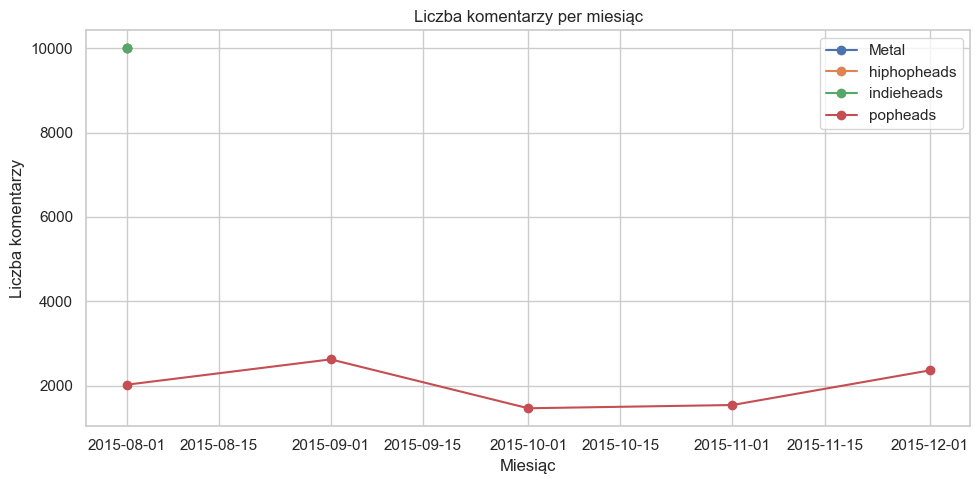

In [20]:
from pathlib import Path

activity = (
    df.groupby(["subreddit", "month"])
    .size()
    .reset_index(name="count")
)

# month to Period — trzeba zamienić na timestamp żeby matplotlib to ogarnął
activity["month_ts"] = activity["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 5))

for sub, group in activity.groupby("subreddit"):
    ax.plot(group["month_ts"], group["count"], marker="o", label=sub)

ax.set_title("Liczba komentarzy per miesiąc")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Liczba komentarzy")
ax.legend()
plt.tight_layout()
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../outputs/figures/activity_per_month.png", dpi=150)
plt.show()

## 3. Długość komentarzy

              mean  median    max
subreddit                        
Metal        200.8   110.0   5452
hiphopheads  131.8    74.0  10000
indieheads   174.4    99.0   9683
popheads     181.3   104.0   9943


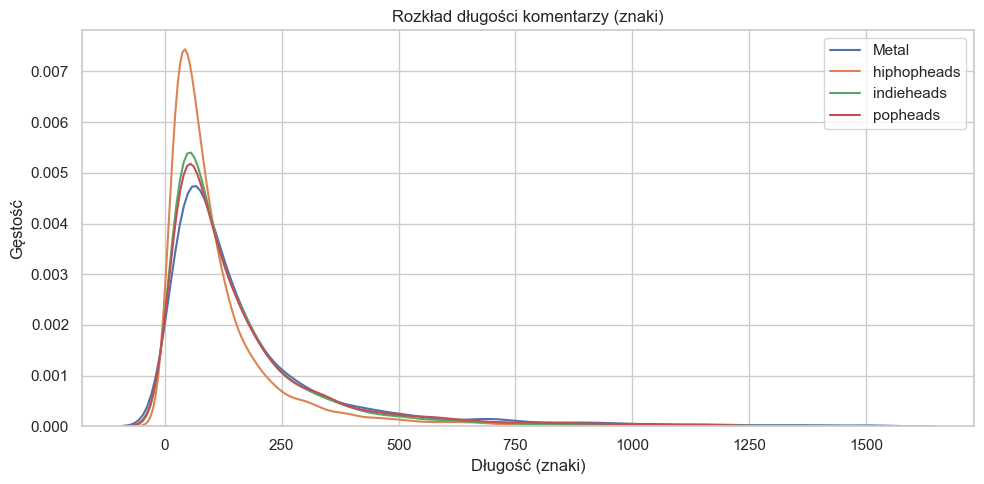

In [26]:
df["body_len"] = df["body"].str.len()

length_stats = df.groupby("subreddit")["body_len"].agg(["mean", "median", "max"]).round(1)
print(length_stats)

fig, ax = plt.subplots(figsize=(10, 5))

for sub, group in df.groupby("subreddit"):
    # przycinamy do 99 percentyla żeby outliery nie psuły wykresu
    cutoff = group["body_len"].quantile(0.99)
    sns.kdeplot(group.loc[group["body_len"] <= cutoff, "body_len"], label=sub, ax=ax)

ax.set_title("Rozkład długości komentarzy (znaki)")
ax.set_xlabel("Długość (znaki)")
ax.set_ylabel("Gęstość")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/comment_length_dist.png", dpi=150)
plt.show()

## 4. Rozkład scorów

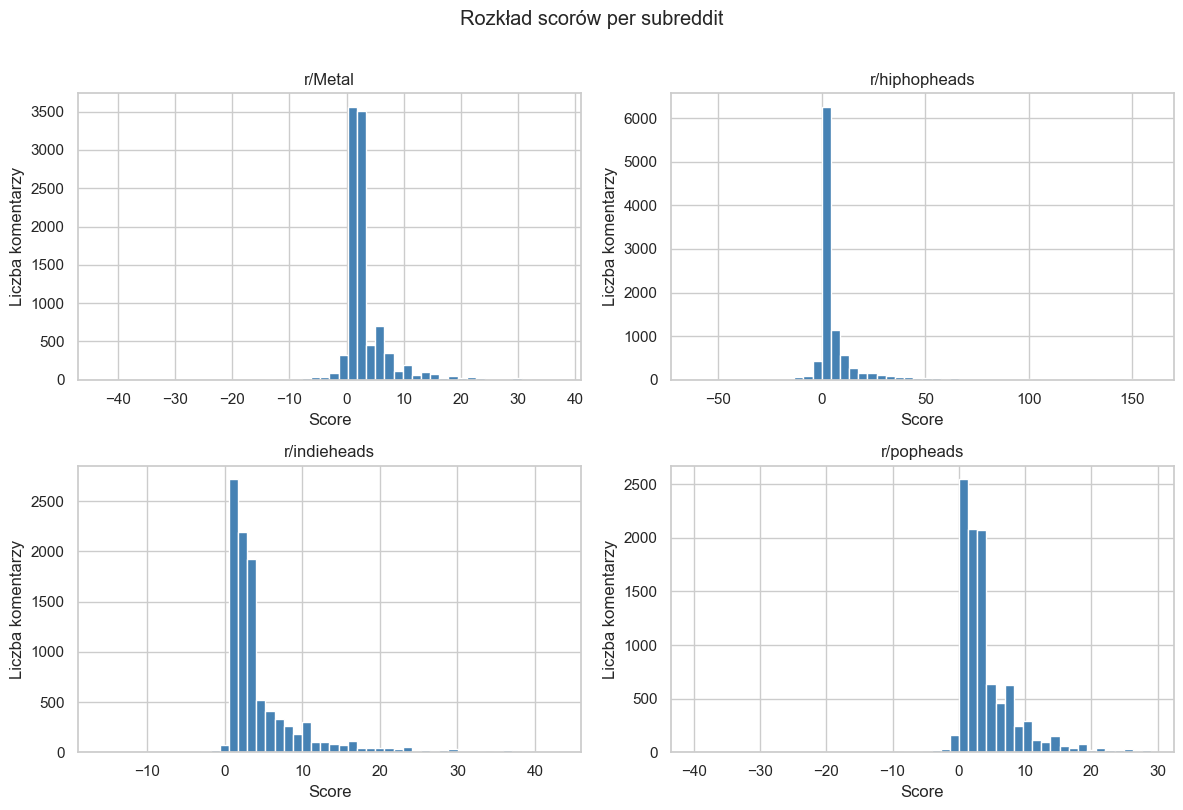

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    cutoff = group["score"].quantile(0.99)
    data = group.loc[group["score"] <= cutoff, "score"]
    axes[i].hist(data, bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(f"r/{sub}")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Liczba komentarzy")

plt.suptitle("Rozkład scorów per subreddit", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/score_dist.png", dpi=150)
plt.show()

## 5. Najpopularniejsi autorzy

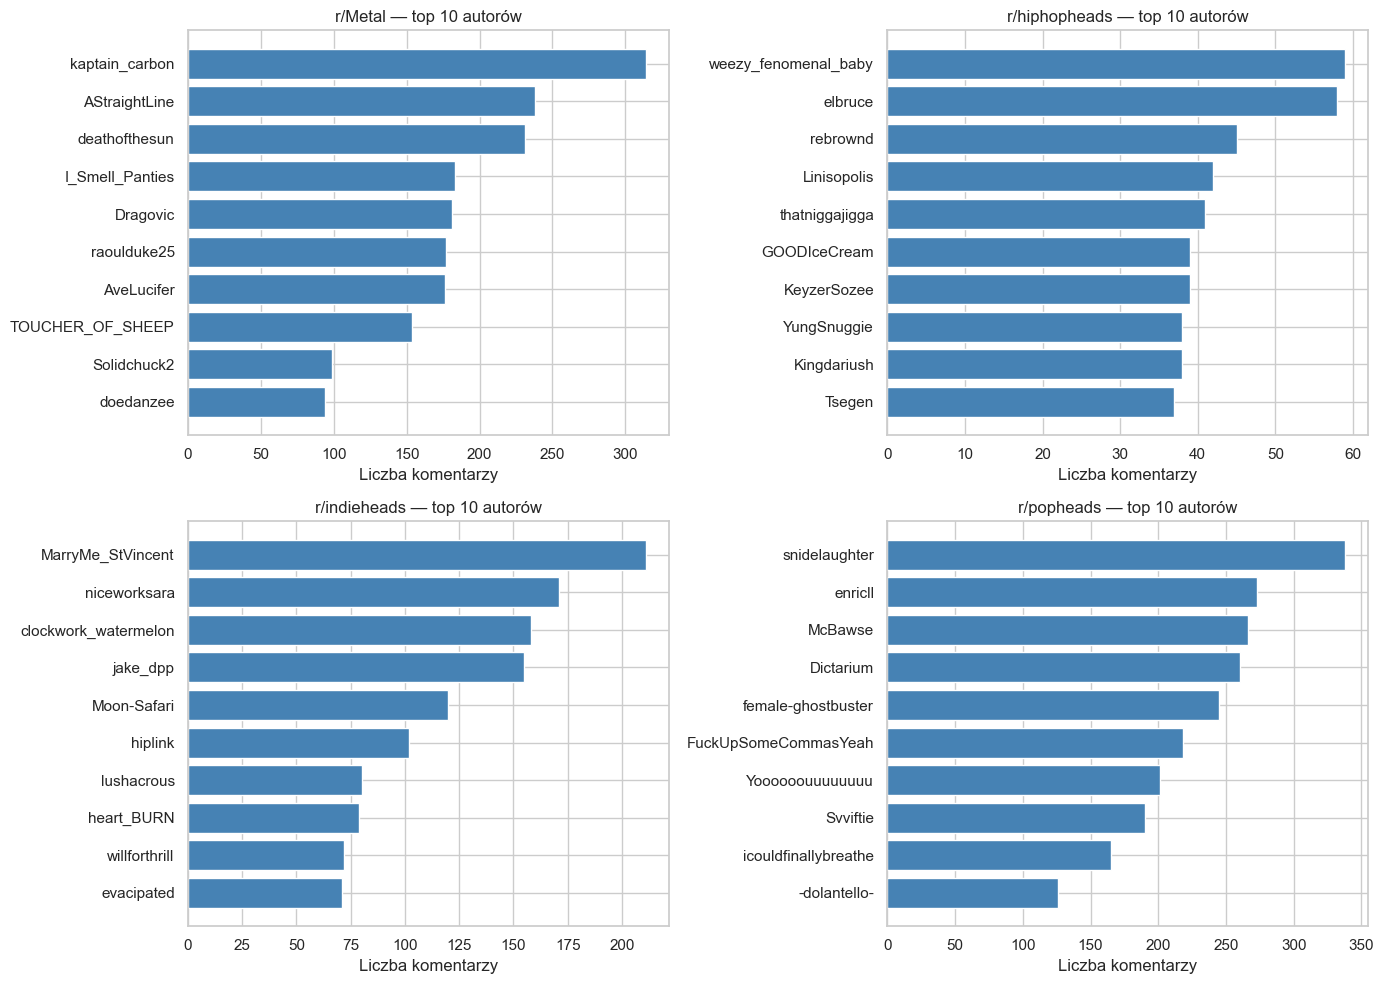

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    top = group["author"].value_counts().head(10)
    axes[i].barh(top.index[::-1], top.values[::-1], color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 autorów")
    axes[i].set_xlabel("Liczba komentarzy")

plt.tight_layout()
plt.savefig("../outputs/figures/top_authors.png", dpi=150)
plt.show()

## 6. Kontrowersyjność i gilded

In [18]:
controversial = (
    df.groupby("subreddit")["controversiality"]
    .mean()
    .mul(100)
    .round(2)
    .rename("% kontrowersyjnych")
)

gilded = (
    df.groupby("subreddit")["gilded"]
    .sum()
    .rename("gilded łącznie")
)

pd.concat([controversial, gilded], axis=1)

,% kontrowersyjnych,gilded łącznie
subreddit,,
Metal,1.44,1
hiphopheads,3.81,2
indieheads,0.62,2
popheads,0.77,0


## Wnioski

- ...
- ...
- ...